In [ ]:
# Imports
!pip install --upgrade cpmpy[z3,pumpkin,exact] --quiet
!pip install matplotlib --quiet
!pip install regionmask --quiet

import cpmpy as cp
import numpy as np
import matplotlib.pyplot as plt

(You can ignore google* and tensor* dependency errors on Google Colab.)



# Session 5: symmetry and dominance breaking

In this fifth exercise session of the Constraint Solving course (CoS) we will tackle the two related topics of **symmetry** and **dominance**.

When looking at the requirements for a "good" model to a constraint problem, we saw three targets:

1) A model that **correctly** represents the problem
2) A model that is **easy** to understand and maintain
3) A model that is solved **efficiently**

In this session we're looking at one specific set of techniques for the third target.

Symmetry and dominance are two important concepts to take into account when modeling a problem. As seen in the lectures, if left in place, they could have negative effects on our solver's performance. Time gets wasted on parts of our search tree which we know is symmetric to an earlier found non-solution. Multiple solutions to our chosen encoding get returned which from the problem description's perspective represent the same solution. Is there any way to reduce the search space, making the model more efficient?

If we can somehow give this insight regarding symmetry and dominance to our solver (through the use of additional "breaking" constraints), this waste can be prevented.

**Useful Resources:**
* CPMpy summary sheet: https://cpmpy.readthedocs.io/en/latest/summary.html
* CPMpy modeling documentation: https://cpmpy.readthedocs.io/en/latest/modeling.html


## Exercise 1: Grocery store prices
A kid goes into a grocery store and buys four items. The cashier charges €7.11,
the kid pays and is about to leave when the cashier calls the kid back, and says:



> "Hold on, I multiplied the four items instead of adding them; I'll try again; Hah, with adding instead of multiplying, the total price still comes to €7.11"

What were the prices of the four items that could lead to this coincidental situation?

1) Write a model that solves the problem.
2) Use `solveAll` to find all the solutions

In [ ]:
"""
TODO: Create the model for our "grocery store prices" problem.
      Next, solve for all solutions using `model.solveAll()`.

HINT: CPMpy can not handle floating point numbers within constraints. Think about how to convert them to integers.
      Be careful with the multiplication of the prices.

HINT: `model.solveAll()` has an optional argument "display". You can provide it with a list of decision variables
       for which you would like the value to be printed on every solution.

       E.g. cp.Model([x > 2, x < 6]).solveAll(display=[x])
           >> [3]
           >> [4]
           >> [5]
"""

# 1) Write the model


# Decision Variables




# Model




# Constraints







# 2) Solve using `solveAll(display=...)`








That's quite a lot of solutions (24). But are they really different from each other? Think about the possible symmetries involved in this problem. Subsets of the above displayed assignments will actually belong to the same symmetry group. They represent the same solution when seen from the perspective of the original problem description.

**Q:** What kind of symmetries are present in this problem? Is it a problem, instance or model symmetry? Value or variable symmetry?



To remove these equivalent solutions, we'll try adding symmetry breaking constraints.

In [ ]:
"""
TODO: Add symmetry breaking constraint(s) to the above model as to keep only
      one solution from each symmetry group. We've seen in the lectures how you
      can break this particular type of symmetry.
"""
# 1) Add symmetry breaking constraint(s)







# 2) Solve again using `solveAll`








## Exercise 2: Map coloring

A classical problem in combinatorial optimisation is that of graph coloring;
given a graph of interconnected nodes, assign a color to each node such that no two connected nodes (through an edge) have the same color. Minimise the number of used colors. We're not really interested in the exact colors that are assigned to each node, instead we like to know the minimum number for colors that are needed for a particular graph.

One application of this is the map coloring problem. In a similar fasion, given a set of neighbouring countries on a map, give each country a color such that no two neighbouring countries have the same color. Again minimise the number of colors used. How many colors are needed for a particular map?

In [ ]:
import geopandas as gpd
import matplotlib.pyplot as plt
import regionmask
from shapely.geometry import MultiPolygon

# Parameters of the Problem
countries = ["B", "NL", "D", "L", "F", "CH"]
neighbors = [("B","NL"),("B","F"),("B","L"),("B","D"),
             ("L","D"),("F","D"),("NL","D"),("CH","F"),("CH","D"), ("L", "F")]

"""
TODO: Model the map coloring problem.

HINT: To somewhat limit the number of solutions getting returned, you can asume an
      upper limit of 4 colors. But what is the smallest nuber of colors that is
      actually needed?

HINT: You can use countries.index(<country>) to get the index of a country in the
      list of countries (and thus also in the list of decision variables).
"""

# Decision Variables
color = cp.intvar(0, 3, shape=len(countries)) # assume 4 colors will definately be enough, maybe less needed?

# Model, constraints








# Solve
def visualise_map():
  """
  'display' function to visualise your map in between solve calls
  Use with solveAll(display=visualise_map)
  """
  solution = {c: color[i].value() for i,c in enumerate(countries)}

  # Load map
  mask = regionmask.defined_regions.natural_earth_v5_0_0.countries_110
  world = mask.to_geodataframe()
  sel = world[world['abbrevs'].isin(countries)].copy()

  # Keep only largest polygon for each country
  sel['geometry'] = sel.geometry.apply(
      lambda g: max(g.geoms, key=lambda x: x.area) if isinstance(g, MultiPolygon) else g
  )

  # Add colors
  sel['colour_value'] = sel['abbrevs'].map({v: solution[v] for v in countries})
  sel['plot_colour'] = sel['colour_value'].map({0:"#e41a1c",1:"#377eb8",2:"#4daf4a",3:"#984ea3"})

  # Plot
  fig, ax = plt.subplots(figsize=(6,6))
  sel.plot(ax=ax, color=sel['plot_colour'], edgecolor='black')
  ax.set_axis_off()
  plt.show()

n = model.solveAll(display=visualise_map)
print(f"Found {n} solutions to the map coloring problem")



If you look at the colorings that are returned, you will notice some symmetry.

**Q:** What kind of symmetries are present in this problem? Is it a problem, instance or model symmetry? Value or variable symmetry?

Find a possible symmetry breaking constraint. There are many options to choose from. No need to try and break all symmetry.

In [ ]:
"""
TODO: Add a possible symmetry breaking constraint. No need to break all symmetry.
"""

# Symmetry breaking constraint





n = model.solveAll(display=visualise_map)
print(f"Found {n} solutions to the map coloring problem")

### BONUS

A challenge: try and break as many symmetries as possible. Through an iterative process, solve the problem, look at the solutions, find symmetries, break them.

In [ ]:
"""
TODO: Try to break as many constraints as possible

WARNING: This is a BONUS question, so don't spend too much time on this if you haven't finished the other exercises yet.
"""

# Even more symmetry breaking constraints
# ...

## Exercise 3: Climbing the Staircase

We want to climb a stair of $n$ steps.

We can move up by one step at a time. We can also move up using two steps at a time. Or make a combination of the two steps sizes. You can generalize this to taking $m$ steps at a time. So given an upper limit $M$ on the step size $m$, we are interested in all the possible combinations of step sizes in order to reach the top at a total of $n$ steps.


For example, a stair of 4 steps (n=4) with maximal step size 2 (M=2) can be climbed with the following sequences:

- 1111 (for one-step moves)
- 112 (one-step, one-step, two-step)
- 121
- 211
- 22


Build on top of the following incomplete model:

In [ ]:
# Parameters of the Problem
n = 4
M = 2

# Decision Variables
steps = cp.intvar(0, M, shape=n, name="steps") # for a stair of size n, at most n steps can be taken -> shape = n

"""
TODO: Finish the model by adding the constraints. Find all possible solutions.
      Don't use any symmetry breaking yet.

HINT: The domain includes the value 0, since depending on the sizes of the taken steps,
      less than n steps are needed. A step size of 0 can be ignored, it is a
      side-effect of the chosen encoding.
"""

# Model, constraints, solve








The provided integer-based encoding (steps) contains again some symmetry (19 solutions). Unlike the previous exercise, this one cannot nicely be categorised into value or variable symmetry. The symmetry types that we saw in the lectures are not a complete categorisation.

**Q**: Describe in your own words how this encoding for the taken steps is symmetric. Why does it not fit under either variable and value symmetry? Is it a problem, instance or model symmetry?

Hint: For the solution, we care about the sequence in which the steps get taken.

Add constraints that break these symmetries.

In [ ]:
"""
TODO: Build upon your previous model. Add constraints to remove the symmetries.

HINT: There are multiple possible ways of breaking this symmetry. Choose your favorite!
"""

# Constraints








# Solve






Now assume that we're only interested in the combination of steps to take, no longer in the sequence. Thus 112 and 121 now do become symmetric solutions.


**Q:** What is the symmetry type of solution 112 and 121 in this new setting?

Since we don't care about the ordering of our steps anymore, the viewpoint that we chose might no longer be the most suitable. Let's try a different one.

In [ ]:
# Parameters of the Problem
n = 4
M = 2

"""
TODO: Choose a more suitable viewpoint for this new setting, one that does not suffer
      from the same symmetries due to the meaningless 0-sized steps. We don't care when
      we take what step size, only the combination of steps needed to reach the top.
      Again solve for all solutions.
"""

# Decision Variables




# Model




# Constraints






# Solve





### BONUS
If we again consider the previous case where the order is important, we got symmetries on the location of '0''s in our steps variable.
You can argue this is a problem symmetry, since the problem specification includes this ambiguity on the number of moves you need to take.
There is however another viewpoint you can take to avoid this symmetry:

In [ ]:
# Parameters of the Problem
n = 4
M = 2

"""
TODO: Create a model for the original sequence dependent problem using a
      different viewpoint that doesn't suffer from symmetry
      (doesn't need the symmetry breaking constraints for the 0's).

HINT: Look into boolean instead of integer decision variables.

HINT: The viewpoint will be completely different, think outside of the box.
"""











## Exercise 4: Weighted Knapsack problem

In the weighted Knapsack problem you are tasked with filling a knapsack with a collection of items. Not all items will fit at the same time. Each item has an associated weight and our knapsack has a strict weight limit for what it can carry. So you'll have to make a selection on which items to include and which to leave behind. Additionally, each item has a certain profit value. All together, we want to fill our knapsack with as much value as possible without going over the weight limit.

This problem has an inherent notion of **dominance**; if two items have the same weight but different value, the higher valued item should always be selected over the lower valued one. So either both are selected, non of the two are selected, or the highest valued one is selected. Any solution which selected the lowest valued of the two but not the other will always be dominated, independent of what the other item selections are.

In [ ]:
"""
Some support code to generate Knapsack problem instances of different sizes.
No need to look at the code.
"""

import random
from typing import Optional

def generate_knapsack_instance(n_items: int, seed: Optional[int] = None, equalweights: bool = False):
    """
    Generate a random instance of the knapsack problem.

    Arguments:
        n_items (int): The number of items to include in the knapsack.
        seed (int): The seed to use for the random number generator.
    """

    if seed is not None:
        random.seed(seed)

    # set bounds
    min_weight, max_weight = 1, 50
    min_profit, max_profit = 1, 50

    # randomly sample
    weights = [random.randint(min_weight, max_weight) for _ in range(n_items)] if not equalweights else [1] * n_items
    profits = [random.randint(min_profit, max_profit) for _ in range(n_items)]

    # calculate capacity as a fraction of total weight
    total_weight = sum(weights)
    capacity = int(total_weight * 0.5)

    # ensure capacity is at least as large as the minimum weight
    capacity = max(capacity, min(weights))

    return weights, profits, capacity

In [ ]:
# Parameters of the Problem
n = 40
random_seed = 42
weights, profits, capacity = generate_knapsack_instance(n, seed=random_seed)

def knapsack(n, weights, profits, capacity):
    """
    TODO: Complete the model implementation. Do not yet use any dominance breaking.
          Next to the model, also return an expression representing the total profit
          of the items collected in the knapsack.
    """
    # Decision Variables




    # Model




    # Constraints




    # Objective




    return model, total_profit

def knapsack_dominance(n, weights, profits, capacity):
    """
    TODO: Copy over your previous model and add dominance breaking constraints.
    """

    # 1) Copied model










    # 2) Dominance breaking









    return model, total_profit

# Print the performance difference between the two models
model, total_profit = knapsack(n, weights, profits, capacity)
model.solve(solver="pumpkin")
print(f"Total profit: {total_profit.value()}")
print(model.status())

model, total_profit = knapsack_dominance(n, weights, profits, capacity)
model.solve(solver="pumpkin")
print(f"Total profit (dominance): {total_profit.value()}")
print(model.status())


We can also run this over a range of problem instances and investigate how the two models (with and without dominance breaking) scale. This should give you an idea of the efficiency improvements you can gain with such modeling techniques.

In [ ]:
runtime_knapsack = []
runtime_knapsack_dominance = []
N = list(range(10, 40, 1))

"""
TODO: Experiment with these different solvers. See how they behave differently to the added dominance constraints.
"""
solver = "pumpkin"
#solver = "ortools"
#solver = "exact"
#solver = "z3" # for this solver, lower the upper limit for N to 30

for n in N:
    weights, profits, capacity = generate_knapsack_instance(n, seed=random_seed)

    model, total_profit = knapsack(n, weights, profits, capacity)
    model.solve(solver=solver)
    runtime_knapsack.append(model.status().runtime)

    model, total_profit = knapsack_dominance(n, weights, profits, capacity)
    model.solve(solver=solver)
    runtime_knapsack_dominance.append(model.status().runtime)

import matplotlib.pyplot as plt
plt.figure(figsize=(8,5))
plt.plot(N, runtime_knapsack, label="Without dominance breaking", marker='o')
plt.plot(N, runtime_knapsack_dominance, label="With dominance breaking", marker='o')

plt.xlabel("n (size of the knapsack problem)")
plt.ylabel("Solver runtime (s)")
plt.title(f"Effect of dominance breaking on knapsack solving time [{solver}]")
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()


## Exercise 5: Heterosquares
A heterosquare of order $n$ is a $n \times n$ square whose elements are distinct integers from 1 to $n^2$ such that the sums of the rows, columns and diagonals are all different.

Here is an example of heterosquare of order 3:


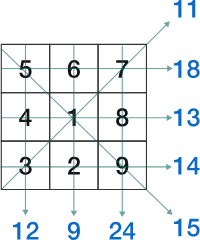

Write a CPMpy Model to solve a heterosquare of order $n$. Think about the symmetries in its solutions.

In [ ]:
# Parameters of the Problem
n = 3

"""
TODO: Model the heterosquare of order n.

HINT: Without symmetry breaking there are 24960 solutions, with all symmetry breaking 3120 (for n = 3).
      Don't try to breake all symmetry at once. First model the problem without any breaking constraints.
      Then look at the solutions / your encodings and try to identify possible locations of symmetry.
      Add a breaking constraint, again look at the solutions and repreat the process.
      Try to break as many symmetries as possible, but no problem if you didn't reach the lower limit of 3120.

HINT: Think about how the grid can be moved, rotated, morphed without changing the sums.
      What can you enforce to prevent these transformations?

HINT: You can call square.diagonal() to get the main diagonal of the matrix.
      Using np.fliplr(square).diagonal() you can get the other diagonal.
"""

# Decision Variables
square = cp.intvar(1, n*n, shape=(n,n))

# Model




# Constraints

# 1) All values in the square should be unique





# 2) All sums should be unique (rows, columns, diagonals)








# 3) Symmetry breaking








# If you want to display a particular solution.
# Be carefull, printing all 24960 solutions might be too much.
def display_solution():
    print("Heterosquare:")
    for i in range(n):
        row = square[i].value()
        print(f"Row {i+1}: {' '.join(map(str, row))} (sum: {sum(row)})")
    print()
    for i in range(n):
        col = square[:,i].value()
        print(f"Column {i+1} sum: {sum(col)}")
    print(f"Diagonal sum: {sum(square.diagonal().value())}")
    print(f"Anti-diagonal sum: {sum(np.fliplr(square).diagonal().value())}")


# Solve





## Exercise 6: Balanced Incomplete Block Design (BIBD)

A BIBD is defined as an arrangement of $a$ distinct objects $(A, B, C, ...)$  into $b$ blocks such that
- each block contains exactly $k$ distinct objects
- each object occurs in exactly $r$ different blocks
- every two distinct objects occur together in exactly $\lambda$ blocks

Below is an example of a BIBD. The columns in the table are the different "blocks".

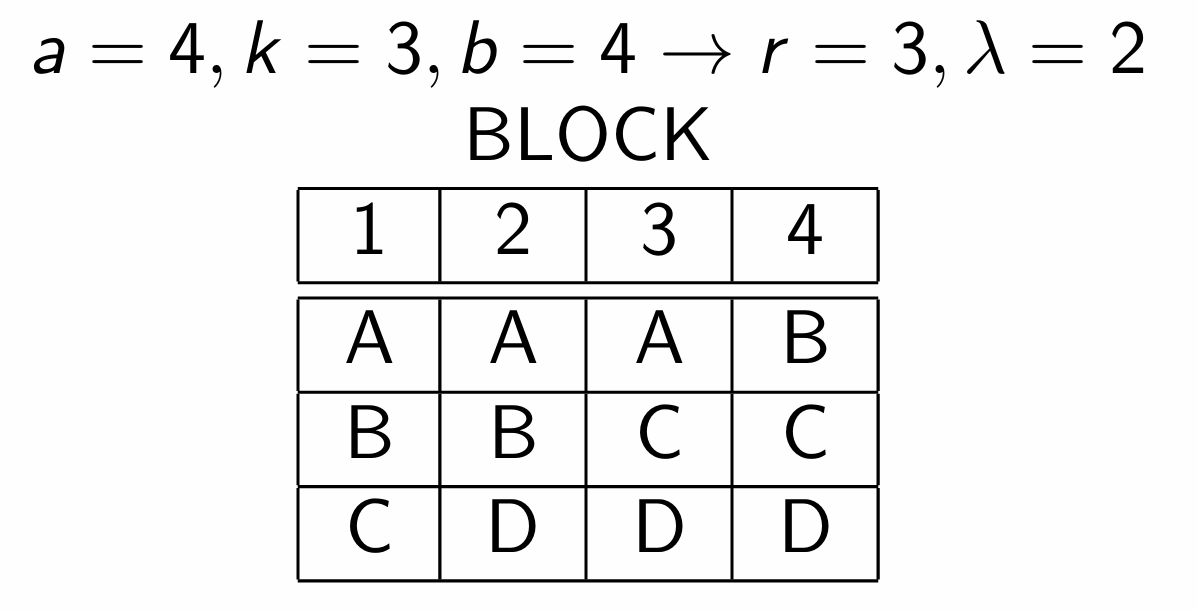

In the first lecture we saw the practical example of "agricultural experiment design".

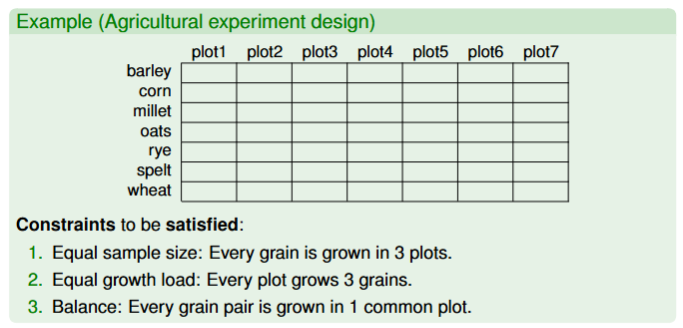

Another way of defining a BIBD is in terms of its incidence matrix, a binary representation using an $a$ by $b$ matrix. For the above BIBD:





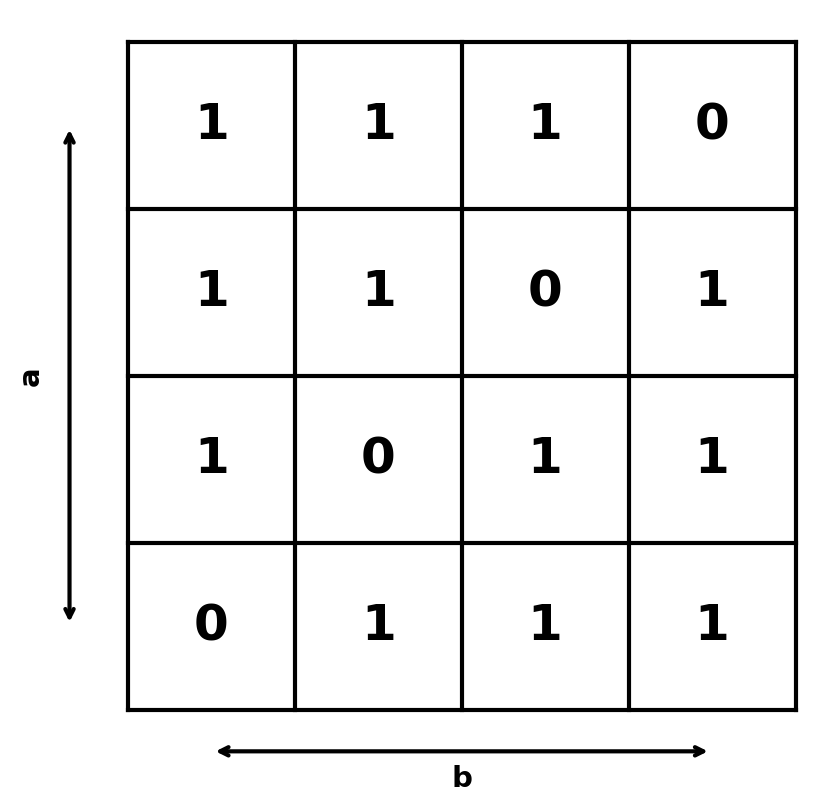

This matrix encodes the exact same information, but now in a binary format. The constraints can now be translated to the following:

- exactly $k$ ones per column
- exactly $r$ ones per row
- a scalar product of $\lambda$ between any pair of distinct rows

Write a CPMpy model to solve a BIBD using the viewpoint of its binary incidence matrix.

In [ ]:
# Parameters of the Problem
a,b = 7,7
r,k = 3,3
l = 1     # lambda

"""
TODO: Model the problem using the "binary incidence matrix" viewpoint
"""

# Decision Variables
# - incidence matrix
#   im = ...





# Model
model = cp.Model()

# Constraints








# Solve
def print_solution():
    # pretty print
    print(f"BIBD: {b} obj, {a} blocks, r={r}, k={k}, l={l}")
    for (i, row) in enumerate(im.value()):
        srow = "".join('X ' if e else '  ' for e in row)
        print(f"Object {i + 1}: [ {srow}]")

# - Print the first 10 solutions
model.solveAll(display=print_solution, solution_limit=10)

# - Try to enumerate all solutions (with an upper limit of 10000)
sols_num = model.solveAll(solution_limit=10000)
print(sols_num)



**Q:** Look at some of the printed solutions, does this problem have any symmetries? If yes, what type of symmetries?


We've encountered a setting where the "Lex-Leader" scheme is applicable. We have a symmetry group $G$. $G$ defines a set of permutation operations which, if applied, result in a different incidence matrix. But from the problem specification's perspective, both matrices still encode the exact same solution. To remove these redundant solutions, we'll have to break the symmetry by defining a collection of lexicographic orderings.

So:

> For each possible permutation of group $G$, we'll have to define a lexicographic constraint to only keep one canonical solution and remove the equivalent symmetric ones.

So we start by defining an order between all symmetrical solutions. Break the symmetries and notice the reduction in the number of solutions.

In [ ]:
# Lex-Leader constraints










# Print the first 10 solutions
model.solveAll(display=print_solution, solution_limit=10)

## Extra's


### The Taxicab Number Problem

Find the numbers that can be expressed as the sum of two cubes in two different ways, i.e. the numbers $n=a^3+b^3=c^3+d^3$ for some a, b, c, d between 1 and 1000. All numbers must be unique: $a!=b!=c!=d$.

Again look at all solutions to check symmetric assignments and add to the model the necessary constraints to rule out the symmetric solutions.


In [ ]:
"""
TODO: Model the taxicab number problem. Add symmetry breaking.
"""












def print_solution():
    print(f"a: {a.value():4d}  b: {b.value():4d}  c: {c.value():4d}  d: {d.value():4d}  n: {n.value():8d}")

nr_solutions = model.solveAll(display=print_solution, solver='pumpkin')
print(f"Found {nr_solutions} solutions")


### Resource-constrained project scheduling problem

We revisit the RCPSP problem from exercise session 3, with a few changes.

A number of activities are to be scheduled. Each activity has a duration and cannot be interrupted/halted. Once started, it must run untill completion. There are no precedence relations between activities. There are 2 renewable resources, each with a maximum capacity of 1, ensuring no more than 1 unit of each resource can be in use at any given time. Each activity has a demand for each resource.
Minimize the starting time of the last activity.

**Q:** What (types of) symmetries do you see?

**Q:** Is there any dominance breaking possible?

In [ ]:
# Parameters of the Problem
#   there are 12 tasks to be scheduled, with 2 resources that can be used.
# - task durations
durations = cp.cpm_array([3, 3, 3, 3, 4, 4, 4, 4, 5, 5, 5, 5])
# - resource requirements
resource_needs = cp.cpm_array([[1, 0], [1, 0], [1, 0], [1, 0], [0, 1], [0, 1], [0, 1], [0, 1], [1, 0], [1, 0], [1, 0], [1, 0]])
# - total resource capacity
resource_capacities = cp.cpm_array([1, 1])
# - problem dimensions
nb_resource = len(resource_capacities)
nb_jobs = len(durations)
max_duration = sum(durations)  # dummy upper bound, can be improved of course

# Decision Variables
start_time = cp.intvar(0, max_duration, shape=nb_jobs)

# Model
model = cp.Model()

"""
TODO: Add the neccesary constraints to the model.
"""

# Constraints
# 1) resource constraints






# 2) break the symmetry







# 3) dominance breaking







# Objective






In [ ]:
"""
Support code to help you visualise the solution.
(nothing the do here)
"""
# Visualize the RCPSP solution
model.solve()

# Get the solution values
start_times = start_time.value()
print(start_times)
end_times = start_times + np.array(durations)

# Create a figure and axis
fig, (ax1, ax2) = plt.subplots(2, 1, figsize=(12, 10), gridspec_kw={'height_ratios': [3, 1]})

# Define colors for each resource
colors = ['#FF9999', '#66B2FF']

# Plot each task as a horizontal bar
for i in range(nb_jobs):
    if durations[i] > 0:  # Skip tasks with zero duration
        ax1.barh(i, durations[i], left=start_times[i], height=0.5,
                 color=colors[np.argmax(resource_needs[i])],
                 alpha=0.8, edgecolor='black')

        # Add task labels
        ax1.text(start_times[i], i, f'Task {i}', va='center', ha='right', fontweight='bold')

# Customize the task plot
ax1.set_xlabel('Time')
ax1.set_ylabel('Tasks')
ax1.set_title('RCPSP Solution Visualization')
ax1.set_ylim(-1, nb_jobs)
ax1.invert_yaxis()  # Invert y-axis to have task 0 at the top

# Add a legend for tasks
legend_elements = [plt.Rectangle((0,0),1,1, facecolor=colors[i], edgecolor='black', alpha=0.8, label=f'Resource {i+1}') for i in range(nb_resource)]
ax1.legend(handles=legend_elements, loc='upper right')

# Show the grid for tasks
ax1.grid(True, axis='x', linestyle='--', alpha=0.7)

# Calculate total resource usage over time
max_time = max(end_times)
resource_usage = np.zeros((nb_resource, max_time + 1))
for i in range(nb_jobs):
    for t in range(start_times[i], end_times[i]):
        for r in range(nb_resource):
            resource_usage[r, t] += resource_needs[i, r]

# Plot total resource usage
for r in range(nb_resource):
    ax2.plot(range(max_time + 1), resource_usage[r], label=f'Resource {r+1}', color=colors[r])

# Plot maximal allowed usage
for r in range(nb_resource):
    ax2.axhline(y=resource_capacities[r], color=colors[r], linestyle='--',
                label=f'Max Resource {r+1}')

ax2.set_xlabel('Time')
ax2.set_ylabel('Total Resource Usage')
ax2.set_title('Total Resource Usage Over Time')
ax2.legend()
ax2.grid(True, linestyle='--', alpha=0.7)

# Adjust layout and display the plot
plt.tight_layout()
plt.show()

# Print the makespan (total project duration)
print(f"Makespan: {max(end_times)}")
